In [ ]:
import time
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
import random
load_dotenv = dotenv.load_dotenv('../.env')

# load local library
from timex import clustering
from timex import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

import datetime
from time import sleep

from aeon import datasets

In [ ]:
dataset = datasets.load_regression("FloodModeling1")

In [ ]:
ts_data = pd.DataFrame(dataset[0].squeeze())
ts_label = dataset[1]

In [ ]:
ts_data['sample'] = ts_data.index 
ts_data_unp = ts_data.melt(id_vars='sample', value_vars=list(range(ts_data.shape[1]-1)))\
                     .sort_values(by=['sample', 'variable'])
ts_data_unp = ts_data_unp.rename(columns = {'variable': 'Time'})

In [ ]:
ts_data_unp

In [ ]:
# create heterogeinity
MAX_CUT_PERC = 0.25
MAX_MASK_PERC = 0.25
MAX_TIME_OVERALL = 265

ts_data_unp_heter = pd.DataFrame()
for s in ts_data_unp['sample'].unique():
    temp_ts = ts_data_unp.loc[(ts_data_unp['sample']==s) & (ts_data_unp['Time']<MAX_TIME_OVERALL), ['sample', 'Time', 'value']]

    max_t = temp_ts['Time'].max()
    # randomly subtract from max_t 
    new_max_t = max_t - MAX_CUT_PERC*np.random.random()*max_t
    temp_ts = temp_ts.query(f'Time<{new_max_t}')

    # random mask from remainder
    val_rem = temp_ts['value'].values
    mask = np.random.rand(val_rem.shape[0]) < MAX_MASK_PERC
    val_rem[mask] = np.nan

    temp_ts = temp_ts.assign(value=val_rem)

    ts_data_unp_heter = pd.concat([ts_data_unp_heter, temp_ts], axis=0)

In [ ]:
# plot 10 random samples
for s in ts_data_unp_heter.sample(n=100)['sample']:
    tsv = ts_data_unp_heter.query(f'sample=={s}')['value']
    tst = ts_data_unp_heter.query(f'sample=={s}')['Time']

    plt.plot(tst, tsv, color='black', alpha=0.2)

In [ ]:
MIN_TIME = 10 
MAX_TIME = 265
MIN_MEAS_COUNT = 10 # measurements
INTERP_RES = 1
ANALYSIS_RES = 7
SMOOTHING_WINDOW = 7 # in days: 4 * INTERP_RES = 360
SMOOTHING_TYPE = 'gaussian_kernel'  # 'gaussian_kernel' or 'rolling_mean', 'gaussian_kernel_simple, 'box_kernel'
META_KEYS = ['sample', 'Time']
ID_KEY = 'sample'
TIME_KEY = 'Time'
RAW_VAL_COL = 'value'

In [ ]:
ts_data_unp_heter = ts_data_unp_heter.reset_index(drop=True)
ts_data_unp_heter = ts_data_unp_heter.dropna(subset='value')

In [ ]:
ts_clusterer = clustering.CrossSectionalClustering(smoothing=True, 
                                                   smoothing_type=SMOOTHING_TYPE,
                                                   smoothing_window_size=SMOOTHING_WINDOW,
                                                   n_skip=2,
                                                   interpolation=True, 
                                                   interpolation_resolution=INTERP_RES,
                                                   interpolation_keep_init=True,
                                                   analysis_resolution=ANALYSIS_RES,
                                                   min_measurements_per_id=MIN_MEAS_COUNT, 
                                                   min_time=MIN_TIME,
                                                   max_time=MAX_TIME,
                                                   n_clusters=3, 
                                                   id_column=ID_KEY, 
                                                   time_column=TIME_KEY,
                                                   feature_columns=[RAW_VAL_COL],
                                                   imputation_method='knn',
                                                   cross_standardisation=True,
                                                   normalise_timeseries= "group",
                                                   normalisation_method="standard",
                                                   add_ts_meta=False,
                                                   verbose=True)

In [ ]:
rand_selection = np.random.choice(ts_data_unp_heter['sample'].unique(), size=100)
ts_clusterer.fit(ts_data_unp_heter.loc[ts_data_unp_heter['sample'].isin(rand_selection)])

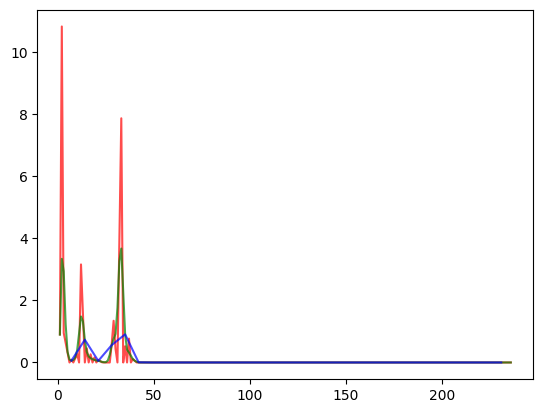

In [17]:
# plot 10 random samples
for s in ts_clusterer.ts_filtered.sample(n=1)['sample']:
    tsv = ts_clusterer.ts_filtered.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_filtered.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='red', alpha=0.7)

    tsv = ts_clusterer.ts_smoothed.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_smoothed.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='green', alpha=0.7)

    tsv = ts_clusterer.ts_smoothed_filtered.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_smoothed_filtered.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='blue', alpha=0.7)

In [ ]:
ts_temp = ts_clusterer.ts_filtered
ts_temp.loc[ts_temp.ID==3565782].head()

In [ ]:
ts_temp = ts_clusterer.ts_interpolated
ts_temp.loc[ts_temp.ID==3565782].head()

In [ ]:
ts_temp = ts_clusterer.ts_smoothed
ts_temp.loc[ts_temp.ID==3565782].head()


In [ ]:
ts_temp = ts_clusterer.ts_normalized
ts_temp.loc[ts_temp.ID==3565782].head()
